In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import compute_returns, moving_average
from src.backtest import backtest_mr, sharpe_ratio, volatility, max_drawdown, backtest_mom
from src.strategy import mean_reversion_strategy, momentum_strategy
from src.visualization import plot_performance

## Mean Reversion, Window = 5

[*********************100%***********************]  1 of 1 completed


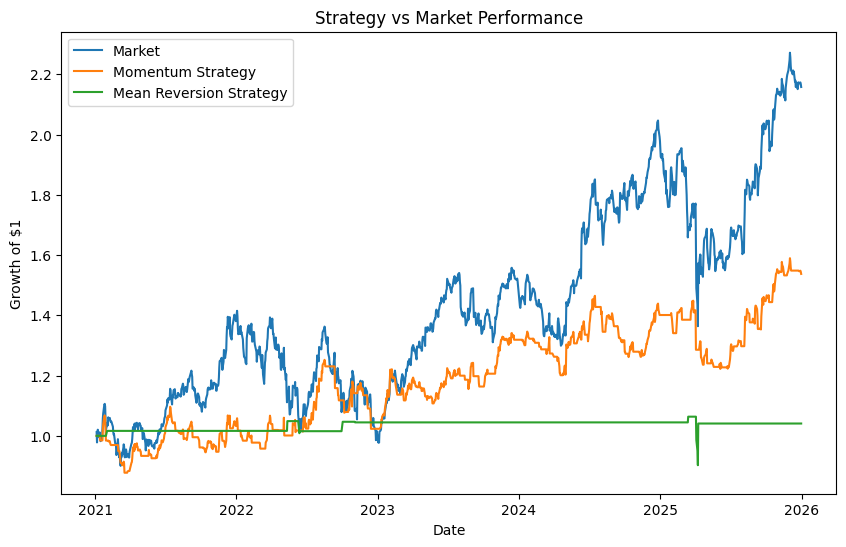

In [2]:
df = get_data('AAPL', '2021-01-01', '2026-01-01')
df = compute_returns(df)
df = moving_average(df)
df["market_cumulative"] = (1 + df["returns"]).cumprod()
df = mean_reversion_strategy(df, window = 5)
df = backtest_mr(df)
df = momentum_strategy(df, window = 5)
df = backtest_mom(df)

plot_performance(df)

In [3]:
print("Returns Sharpe Ratio: " + str(sharpe_ratio(df['returns'])))
print("Mean Reversion Strategy Returns Sharpe Ratio: " + str(sharpe_ratio(df['strategy_returns_mr'])))
print("Momentum Strategy Returns Sharpe Ratio: " + str(sharpe_ratio(df['strategy_returns_mom'])))

Returns Sharpe Ratio: 0.6937717203336888
Mean Reversion Strategy Returns Sharpe Ratio: 0.1348620325036127
Momentum Strategy Returns Sharpe Ratio: 0.5691356884218054


In [4]:
strategy_sharpe = sharpe_ratio(df["strategy_returns_mr"])
strategy_vol = volatility(df["strategy_returns_mr"])
strategy_max_dd = max_drawdown(df["cumulative_returns_mr"])

print("Mean Reversion Risk Metrics")
print(f"Sharpe: {strategy_sharpe:.2f}")
print(f"Volatility: {strategy_vol:.2f}")
print(f"Max Drawdown: {strategy_max_dd:.2%}")

Mean Reversion Risk Metrics
Sharpe: 0.13
Volatility: 0.09
Max Drawdown: -15.14%


## Mean Reversion, Window = 10

[*********************100%***********************]  1 of 1 completed


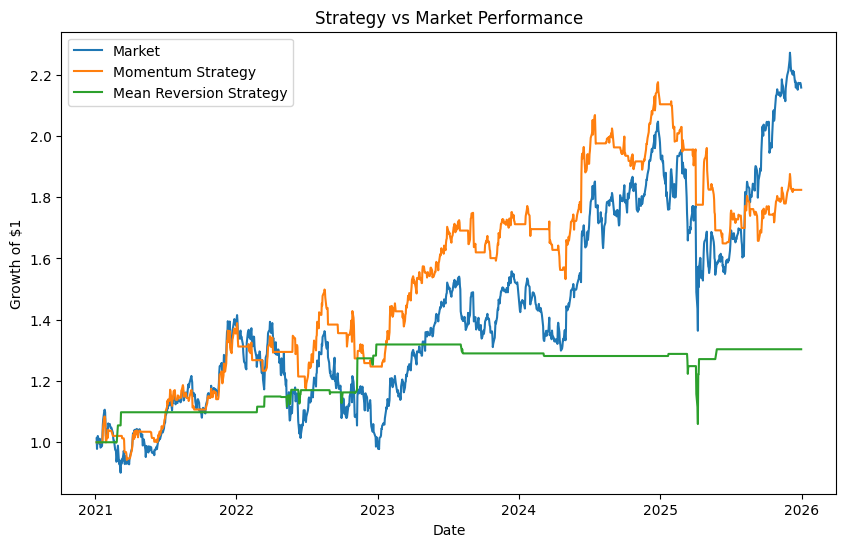

In [5]:
df = get_data('AAPL', '2021-01-01', '2026-01-01')
df = compute_returns(df)
df = moving_average(df)
df["market_cumulative"] = (1 + df["returns"]).cumprod()
df = mean_reversion_strategy(df)
df = backtest_mr(df)
df = momentum_strategy(df)
df = backtest_mom(df)

plot_performance(df)

In [6]:
strategy_sharpe = sharpe_ratio(df["strategy_returns_mr"])
strategy_vol = volatility(df["strategy_returns_mr"])
strategy_max_dd = max_drawdown(df["cumulative_returns_mr"])

print("Mean Reversion Risk Metrics")
print(f"Sharpe: {strategy_sharpe:.2f}")
print(f"Volatility: {strategy_vol:.2f}")
print(f"Max Drawdown: {strategy_max_dd:.2%}")

Mean Reversion Risk Metrics
Sharpe: 0.54
Volatility: 0.11
Max Drawdown: -19.69%


## Mean Reversion, Window = 20

[*********************100%***********************]  1 of 1 completed


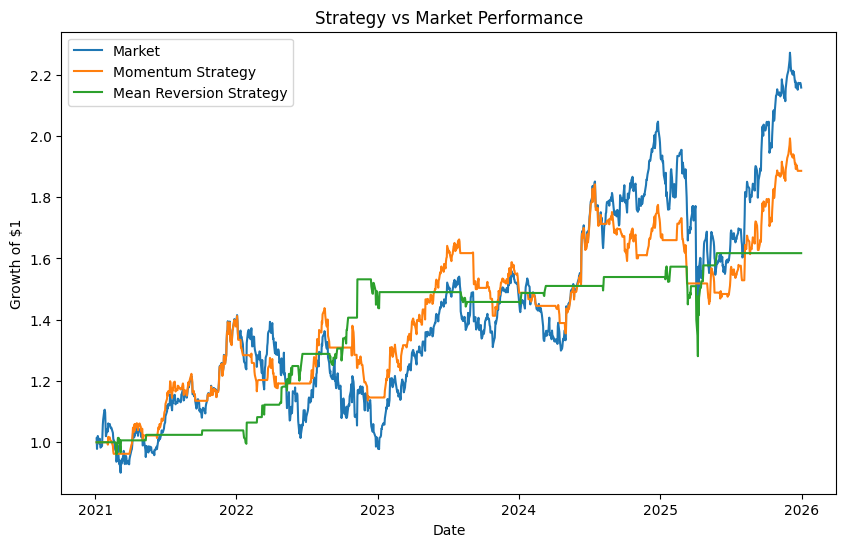

In [7]:
df = get_data('AAPL', '2021-01-01', '2026-01-01')
df = compute_returns(df)
df = moving_average(df)
df["market_cumulative"] = (1 + df["returns"]).cumprod()
df = mean_reversion_strategy(df, window = 20)
df = backtest_mr(df)
df = momentum_strategy(df, window = 20)
df = backtest_mom(df)

plot_performance(df)

In [8]:
strategy_sharpe = sharpe_ratio(df["strategy_returns_mr"])
strategy_vol = volatility(df["strategy_returns_mr"])
strategy_max_dd = max_drawdown(df["cumulative_returns_mr"])

print("Mean Reversion Risk Metrics")
print(f"Sharpe: {strategy_sharpe:.2f}")
print(f"Volatility: {strategy_vol:.2f}")
print(f"Max Drawdown: {strategy_max_dd:.2%}")

Mean Reversion Risk Metrics
Sharpe: 0.77
Volatility: 0.14
Max Drawdown: -18.62%


## Mean Reversion, Window = 50

[*********************100%***********************]  1 of 1 completed


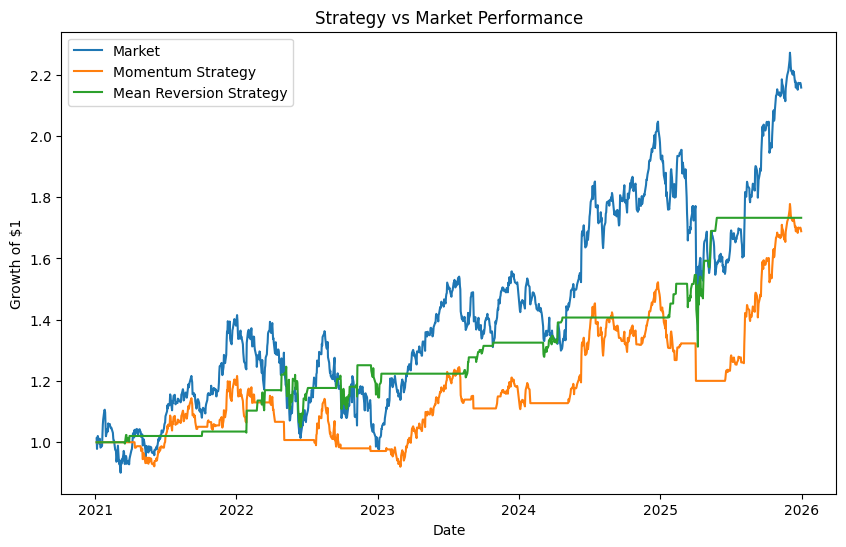

In [9]:
df = get_data('AAPL', '2021-01-01', '2026-01-01')
df = compute_returns(df)
df = moving_average(df)
df["market_cumulative"] = (1 + df["returns"]).cumprod()
df = mean_reversion_strategy(df, window = 50)
df = backtest_mr(df)
df = momentum_strategy(df, window = 50)
df = backtest_mom(df)

plot_performance(df)

In [10]:
strategy_sharpe = sharpe_ratio(df["strategy_returns_mr"])
strategy_vol = volatility(df["strategy_returns_mr"])
strategy_max_dd = max_drawdown(df["cumulative_returns_mr"])

print("Mean Reversion Risk Metrics")
print(f"Sharpe: {strategy_sharpe:.2f}")
print(f"Volatility: {strategy_vol:.2f}")
print(f"Max Drawdown: {strategy_max_dd:.2%}")

Mean Reversion Risk Metrics
Sharpe: 0.78
Volatility: 0.16
Max Drawdown: -15.82%


## Best MR Window, Fixed Threshold Test

[*********************100%***********************]  1 of 1 completed

Market (Buy & Hold) Returns Sharpe Ratio: 0.6937717203336888
Best strategy window: 48
Best Sharpe ratio: 0.8346



/Users/noel/Desktop/quant-research-system/src/backtest.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns) / np.std(returns) * np.sqrt(252)
/Users/noel/Desktop/quant-research-system/src/backtest.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns) / np.std(returns) * np.sqrt(252)


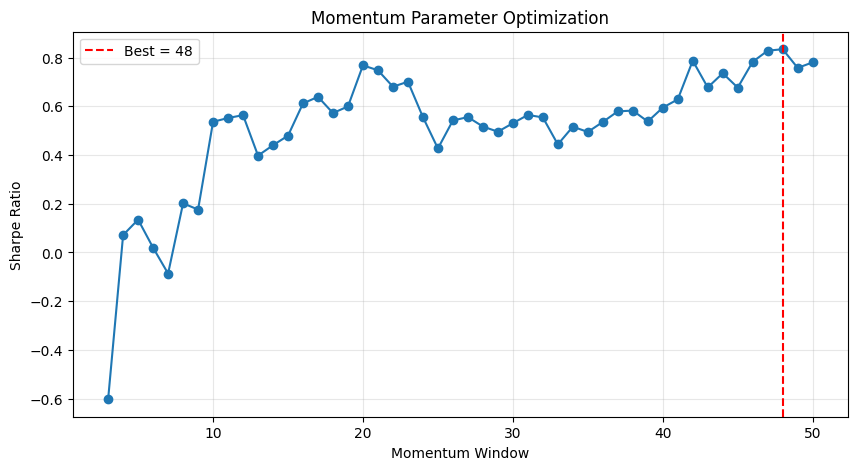

In [ ]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = compute_returns(base_df)
base_df["market_cumulative"] = (1 + base_df["returns"]).cumprod()

bestsharpe = float('-inf')
bestsharpe_strat = None

params = []
sharpes = []

for i in range(1, 51):
    df = base_df.copy()

    df = mean_reversion_strategy(df, i)
    df = backtest_mr(df)

    sharpe = sharpe_ratio(df['strategy_returns_mr'].dropna())

    params.append(i)
    sharpes.append(sharpe)

    if sharpe > bestsharpe:
        bestsharpe = sharpe
        bestsharpe_strat = i


print(f"Market (Buy & Hold) Returns Sharpe Ratio: {sharpe_ratio(base_df['returns'])}")
print(f"Best strategy window: {bestsharpe_strat}")
print(f"Best Sharpe ratio: {bestsharpe:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(params, sharpes, marker='o')
plt.axvline(bestsharpe_strat,
            color='red',
            linestyle='--',
            label=f'Best = {bestsharpe_strat}')
plt.xlabel('Momentum Window')
plt.ylabel('Sharpe Ratio')
plt.title('Momentum Parameter Optimization')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

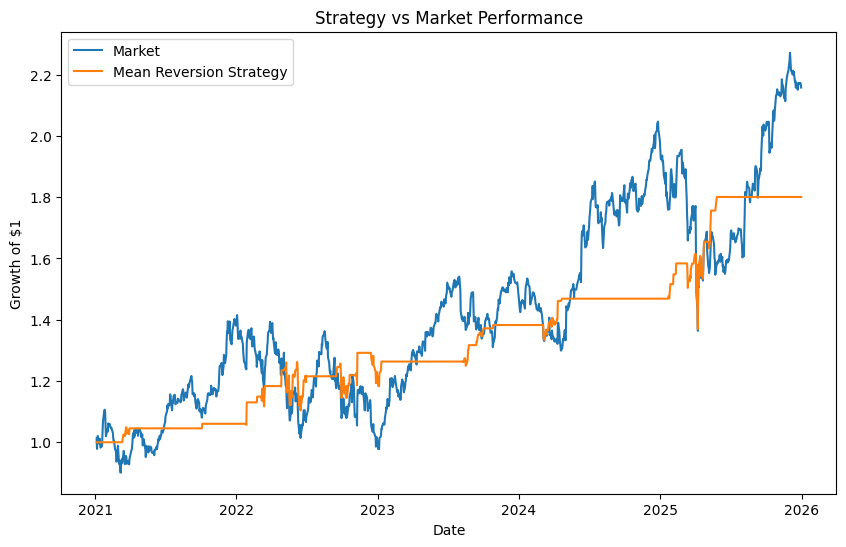

In [22]:
df = base_df.copy()
df = mean_reversion_strategy(df, bestsharpe_strat)
#df = mean_reversion_strategy(df, 10)
df = backtest_mr(df)

plot_performance(df)

## Best MR Window & Threshold Test

[*********************100%***********************]  1 of 1 completed
/Users/noel/Desktop/quant-research-system/src/backtest.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns) / np.std(returns) * np.sqrt(252)
/Users/noel/Desktop/quant-research-system/src/backtest.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns) / np.std(returns) * np.sqrt(252)
/Users/noel/Desktop/quant-research-system/src/backtest.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns) / np.std(returns) * np.sqrt(252)
/Users/noel/Desktop/quant-research-system/src/backtest.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns) / np.std(returns) * np.sqrt(252)
/Users/noel/Desktop/quant-research-system/src/backtest.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns) / np.std(returns) * np.sqrt(252)
/Users/noel/Desktop/quant-resea

Market (Buy & Hold) Sharpe Ratio: 0.6938

Best overall parameters:
Window (i): 34
Threshold (j): 0.03
Sharpe Ratio: 1.0674


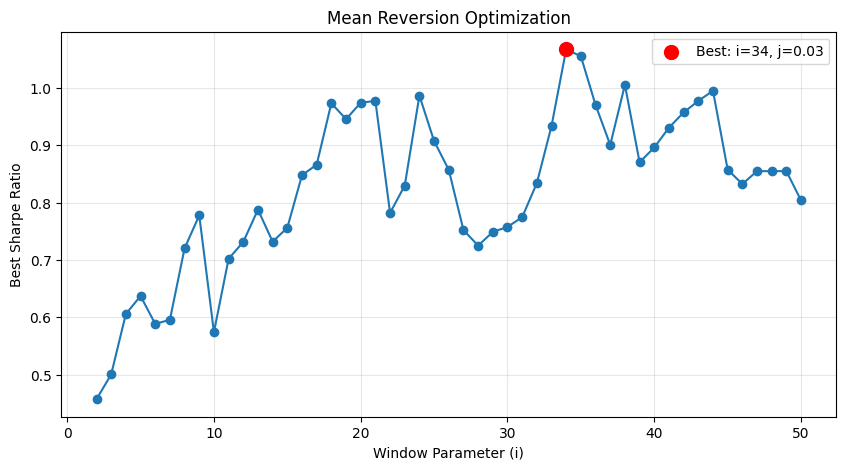

In [23]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = compute_returns(base_df)
base_df["market_cumulative"] = (1 + base_df["returns"]).cumprod()

bestsharpe = float('-inf')
best_i = None
best_j = None

windowparams = []
sharpes = []
best_js = []

for i in range(1, 51):

    best_sharpe_for_i = float('-inf')
    best_j_for_i = None

    for j in range(0, 101):
        threshold = j / 100

        df = base_df.copy()

        df = mean_reversion_strategy(df, i, threshold)
        df = backtest_mr(df)

        sharpe = sharpe_ratio(
            df['strategy_returns_mr'].dropna()
        )

        # Best j for this i
        if sharpe > best_sharpe_for_i:
            best_sharpe_for_i = sharpe
            best_j_for_i = threshold

        # Best overall (i, j)
        if sharpe > bestsharpe:
            bestsharpe = sharpe
            best_i = i
            best_j = threshold

    windowparams.append(i)
    sharpes.append(best_sharpe_for_i)
    best_js.append(best_j_for_i)

print(
    f"Market (Buy & Hold) Sharpe Ratio: "
    f"{sharpe_ratio(base_df['returns']):.4f}"
)

print("\nBest overall parameters:")
print(f"Window (i): {best_i}")
print(f"Threshold (j): {best_j:.2f}")
print(f"Sharpe Ratio: {bestsharpe:.4f}")

# Plot best Sharpe for each i
plt.figure(figsize=(10, 5))
plt.plot(windowparams, sharpes, marker='o')

plt.scatter(
    best_i,
    bestsharpe,
    color='red',
    s=100,
    zorder=5,
    label=f'Best: i={best_i}, j={best_j:.2f}'
)

plt.xlabel('Window Parameter (i)')
plt.ylabel('Best Sharpe Ratio')
plt.title('Mean Reversion Optimization')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

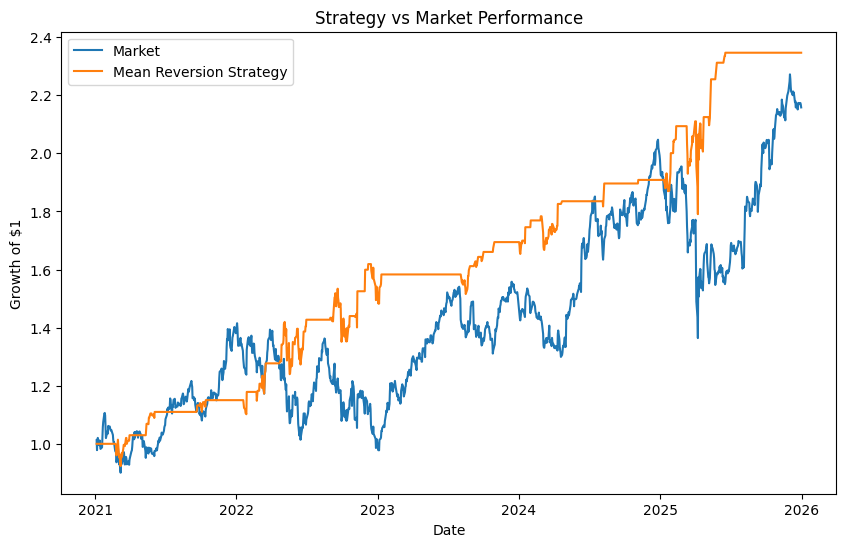

In [24]:
df = base_df.copy()
df = mean_reversion_strategy(df, best_i, best_j)
#df = mean_reversion_strategy(df, 10)
df = backtest_mr(df)

plot_performance(df)

In [25]:
strategy_sharpe = sharpe_ratio(df["strategy_returns_mr"])
strategy_vol = volatility(df["strategy_returns_mr"])
strategy_max_dd = max_drawdown(df["cumulative_returns_mr"])

print("Mean Reversion Risk Metrics")
print(f"Sharpe: {strategy_sharpe:.2f}")
print(f"Volatility: {strategy_vol:.2f}")
print(f"Max Drawdown: {strategy_max_dd:.2%}")

Mean Reversion Risk Metrics
Sharpe: 1.07
Volatility: 0.17
Max Drawdown: -15.14%


## Best Momentum vs Best Mean Reversion

Market (Buy & Hold) Returns Sharpe Ratio: 0.6937717203336888
Best strategy window: 6
Best Sharpe ratio: 0.9922


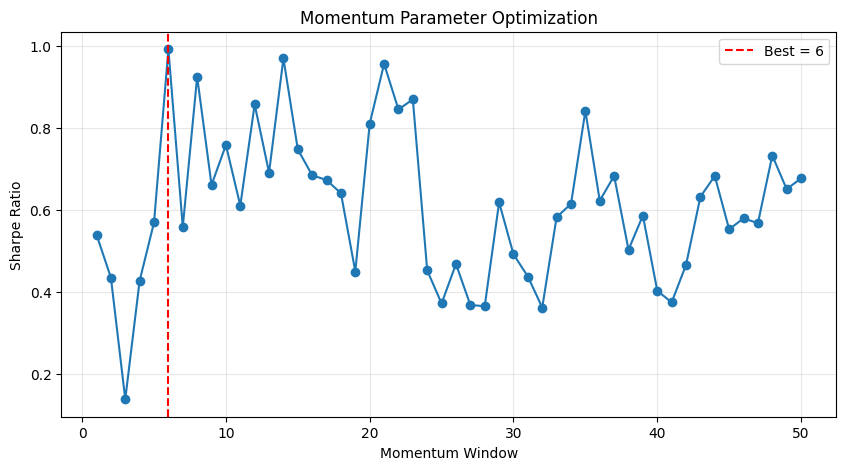

In [26]:
base_df = df.copy()

bestsharpe = float('-inf')
bestsharpe_strat = None

params = []
sharpes = []

for i in range(1, 51):
    df = base_df.copy()

    df = momentum_strategy(df, i)
    df = backtest_mom(df)

    sharpe = sharpe_ratio(df['strategy_returns_mom'].dropna())

    params.append(i)
    sharpes.append(sharpe)

    if sharpe > bestsharpe:
        bestsharpe = sharpe
        bestsharpe_strat = i

print(f"Market (Buy & Hold) Returns Sharpe Ratio: {sharpe_ratio(base_df['returns'])}")
print(f"Best strategy window: {bestsharpe_strat}")
print(f"Best Sharpe ratio: {bestsharpe:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(params, sharpes, marker='o')
plt.axvline(bestsharpe_strat,
            color='red',
            linestyle='--',
            label=f'Best = {bestsharpe_strat}')
plt.xlabel('Momentum Window')
plt.ylabel('Sharpe Ratio')
plt.title('Momentum Parameter Optimization')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

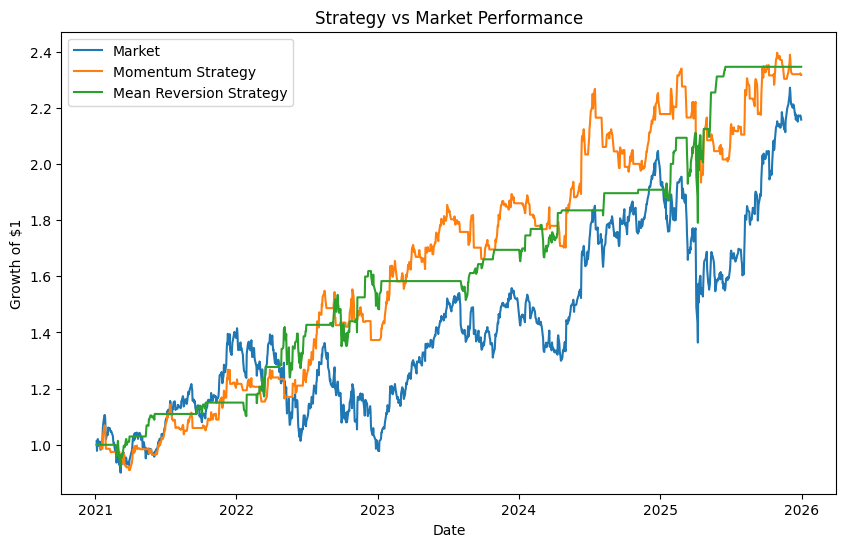

In [27]:
df = base_df.copy()
df = momentum_strategy(df, bestsharpe_strat)
#df = momentum_strategy(df, 49)
df = backtest_mom(df)

plot_performance(df)